# Price Elasticity-Based Promotion Optimizer
Parinda Lertpituckchaiporn (Dear)    |    BOTNOI CONSULTING Data Science Trainee Test Project

<img src="./workflow diagram.png" width="500">

## STEP 1: Business Understanding
SME ในธุรกิจ Retail  กำลังถูกบีบจากต้นทุนที่พุ่งสูงและสินค้าจีนทุนต่ำที่ท่วมตลาด
ทำให้หลายธุรกิจพึ่งพาการลดราคาเพื่อกระตุ้นยอดขาย    
แต่การทำ Promotion แบบเดาสุ่มไม่มีข้อมูลรองรับ
ยิ่งทำลายเนื้อกำไร (Margin) โดยไม่จำเป็นและไม่ได้ช่วยเพิ่มรายได้จริง
- บางสินค้าลด 20% แต่ยอดขายไม่ขึ้นเลย → Margin หาย เปล่าประโยชน์
- บางสินค้าลดแค่ 5% ก็ขายดีขึ้นมาก → แต่กลับไม่จัดโปรโมชั่น เสียโอกาส

### Solution ที่เสนอ: Price Elasticity-Based Promotion Optimizer

**ทำอะไร?**  
ประมาณค่า Price Elasticity of Demand (PED) ของแต่ละสินค้า จากข้อมูลขายจริง  
และหาส่วนลดที่เหมาะสมสำหรับแต่ละสินค้า เพื่อ maximize Revenue และ Profit จากข้อมูลพฤติกรรมการซื้อจริงที่ผ่านมา

### KPI 
| KPI | Formula | Business Objective |
|------|------------|-------------------|
| **Profit Margin (%)** | (Revenue - COGS) / Revenue × 100 | เพิ่มขึ้นเมื่อเทียบกับกลยุทธ์เดิม (Baseline) เพื่อรักษาความสามารถในการทำกำไร |
| **Promotion ROI (%)** | (Incremental Financial Gain / Total Discount Cost) × 100 | วัดความคุ้มค่าของงบประมาณส่วนลด มากกว่า 100% แสดงว่าโปรโมชั่นสร้างผลตอบแทนมากกว่าต้นทุนส่วนลด |
| **Revenue Uplift (%)** | (Revenue_after − Revenue_baseline) / Revenue_baseline × 100 | เพิ่มยอดขายจากการใช้กลยุทธ์โปรโมชั่นที่เหมาะสมกับพฤติกรรมลูกค้า |

## STEP 2: Data Understanding & Exploration (EDA)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
sales    = pd.read_csv('./data/sales_transaction.csv')
product  = pd.read_csv('./data/product_master.csv')
promo    = pd.read_csv('./data/promotion_master.csv')
customer = pd.read_csv('./data/customer_master.csv')
store    = pd.read_csv('./data/store_master.csv')
print(f'sales_transaction {sales.shape}')
print(f'product_master {product.shape}')
print(f'promotion_master {promo.shape}')
print(f'customer_master {customer.shape}')
print(f'store_master {store.shape}')

sales_transaction (5050, 8)
product_master (88, 4)
promotion_master (40, 5)
customer_master (515, 2)
store_master (20, 2)


#### 2.1 EDA: Sales Transaction

In [3]:
print(sales.head(5))

print('\nData Types:')
print(sales.dtypes)

print('\nNull Count:')
print(sales.isnull().sum())

print(f'\nDuplicate Rows: {sales.duplicated().sum()}')

              datetime product_id   price  qty customer_id promotion_id  \
0  2024-05-22 19:33:00       P049  103.25   13       C0179          NaN   
1  2024-03-03 20:21:00       P073  125.81  -14       C0416     PROMO002   
2  2024-06-28 17:05:00       P001  136.05    6       C0312          NaN   
3  2024-09-20 12:43:00       P027  145.15   16       C0441          NaN   
4  2024-09-18 20:31:00       P078  184.30   12       C0330          NaN   

  store_id    po_id  
0      S20  PO00001  
1      S18  PO00002  
2      S10  PO00003  
3      S19  PO00004  
4      S15  PO00005  

Data Types:
datetime         object
product_id       object
price           float64
qty               int64
customer_id      object
promotion_id     object
store_id         object
po_id            object
dtype: object

Null Count:
datetime           0
product_id         0
price             20
qty                0
customer_id      474
promotion_id    4179
store_id           0
po_id              0
dtype: int64

Dup

#### 2.2 EDA: Product Master

In [4]:
print(product.head(5))

print('\nData Types:')
print(product.dtypes)

print('\nNull Count:')
print(product.isnull().sum())

print('\nUnique product_taxonomies:')
print(product['product_taxonomies'].value_counts())

print(f'\nDuplicate Rows: {product.duplicated().sum()}')

  product_id       price product_taxonomies   cogs
0       P001      140.47          commodity  48.18
1       P002      215.55          commodity  48.07
2       P003       34.46          commodity  11.37
3       P004  252.2 baht                NaN  51.20
4       P005      293.87                NaN  68.18

Data Types:
product_id             object
price                  object
product_taxonomies     object
cogs                  float64
dtype: object

Null Count:
product_id            0
price                 0
product_taxonomies    4
cogs                  0
dtype: int64

Unique product_taxonomies:
product_taxonomies
dry_food      15
household     15
fresh_food    15
beverage      14
snack         12
commodity      9
beverage       3
Beverage       1
Name: count, dtype: int64

Duplicate Rows: 8


#### 2.3 EDA: Promotion Master

In [5]:
print(promo.head(5))

print('\nData Types:')
print(promo.dtypes)

print('\nNull Count:')
print(promo.isnull().sum())

print(f'\nDuplicate Rows: {promo.duplicated().sum()}')

  promotion_id  discount           product_id  start_date    end_date
0     PROMO001      0.50            P042,P008  2024-05-18  2024-07-06
1     PROMO002      0.19  P035,P009,P028,P073  2024-01-17  2024-01-30
2     PROMO003      0.50  P059,P019,P034,P018  2024-04-18  2024-06-05
3     PROMO004      0.09       P075,P055,P052  2024-10-14  2024-10-22
4     PROMO005      0.50  P012,P007,P015,P020  2024-04-22  2024-04-29

Data Types:
promotion_id     object
discount        float64
product_id       object
start_date       object
end_date         object
dtype: object

Null Count:
promotion_id    0
discount        0
product_id      0
start_date      0
end_date        0
dtype: int64

Duplicate Rows: 0


#### 2.4 EDA: Store Master

In [6]:
print(store.head(5))

print('\nData Types:')
print(store.dtypes)

print('\nNull Count:')
print(store.isnull().sum())

print('\nUnique Store Taxonomies:')
print(store['store_taxonomies'].value_counts())

print(f'\nDuplicate Rows: {store.duplicated().sum()}')

  store_id store_taxonomies
0      S01      hypermarket
1      S02      convenience
2      S03      supermarket
3      S04        mini_mart
4      S05        specialty

Data Types:
store_id            object
store_taxonomies    object
dtype: object

Null Count:
store_id            0
store_taxonomies    0
dtype: int64

Unique Store Taxonomies:
store_taxonomies
hypermarket          4
supermarket          4
convenience          3
mini_mart            3
specialty            3
CONVENIENCE          1
Convenience          1
convenience store    1
Name: count, dtype: int64

Duplicate Rows: 0


#### 2.5 EDA: Customer Master

In [7]:
print(customer.head(5))

print('\nData Types:')
print(customer.dtypes)

print('\nNull Count:')
print(customer.isnull().sum())

print('\nUnique Customer Segments:')
print(customer['customer_taxonomies'].value_counts())

print(f'\nDuplicate Rows: {customer.duplicated().sum()}')

  customer_id customer_taxonomies
0       C0001               loyal
1       C0002          occasional
2       C0003                 new
3       C0004             at_risk
4       C0005             churned

Data Types:
customer_id            object
customer_taxonomies    object
dtype: object

Null Count:
customer_id             0
customer_taxonomies    12
dtype: int64

Unique Customer Segments:
customer_taxonomies
new           101
loyal         100
churned        99
occasional     98
at_risk        97
LOYAL           4
ocasional       2
Loyal           1
loyl            1
Name: count, dtype: int64

Duplicate Rows: 15


#### 2.6 EDA: Promotion Coverage Analysis

Total Transactions  : 5,050
With Promotion      : 871  (17.2%)
Without Promotion   : 4,179 (82.8%)


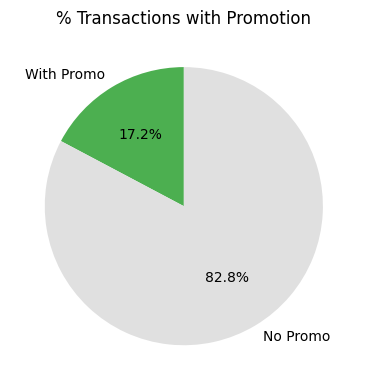

In [8]:
total_tx    = len(sales)
promo_tx    = sales['promotion_id'].notna().sum()
no_promo_tx = total_tx - promo_tx

print(f'Total Transactions  : {total_tx:,}')
print(f'With Promotion      : {promo_tx:,}  ({promo_tx/total_tx:.1%})')
print(f'Without Promotion   : {no_promo_tx:,} ({no_promo_tx/total_tx:.1%})')

# Pie chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.pie([promo_tx, no_promo_tx], labels=['With Promo', 'No Promo'],
       autopct='%1.1f%%', colors=['#4CAF50', '#e0e0e0'], startangle=90)
ax.set_title('% Transactions with Promotion')
plt.tight_layout()
plt.show()

#### 2.7 EDA: Price & Quantity Distribution in Sales

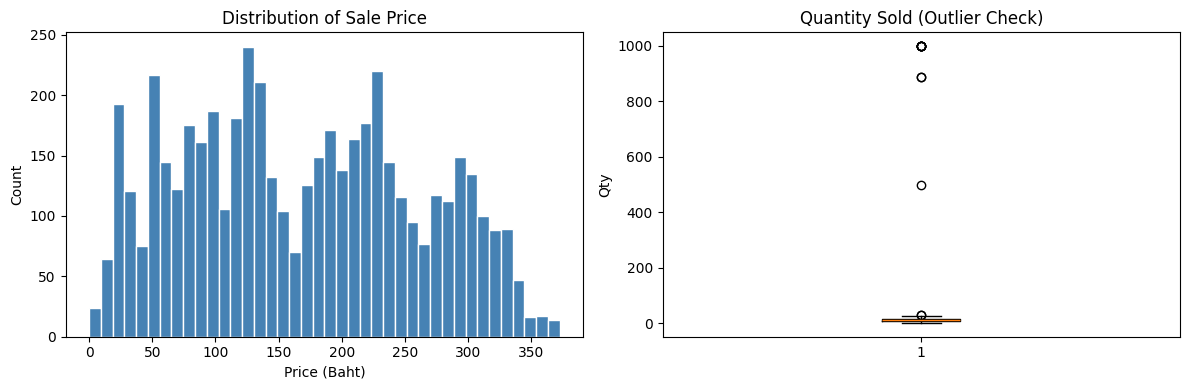

Price Stats:
count    4990.00
mean      167.43
std        91.97
min         0.00
25%        91.32
50%       164.54
75%       237.88
max       372.50
Name: price, dtype: float64

Quantity Stats:
count    5010.00
mean       14.28
std        41.62
min         1.00
25%         9.00
50%        13.00
75%        16.00
max       999.00
Name: qty, dtype: float64


In [9]:
sales_pos = sales[sales['qty'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Price Distribution
axes[0].hist(sales_pos['price'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Sale Price')
axes[0].set_xlabel('Price (Baht)')
axes[0].set_ylabel('Count')

# Quantity Boxplot
axes[1].boxplot(sales_pos['qty'])
axes[1].set_title('Quantity Sold (Outlier Check)')
axes[1].set_ylabel('Qty')

plt.tight_layout()
plt.show()

# Descriptive Statistics
print('Price Stats:')
print(sales_pos['price'].describe().round(2))

print('\nQuantity Stats:')
print(sales_pos['qty'].describe().round(2))

**พบว่า Quantity Distribution มี outliers**    
เลยทำการสำรวจค่า outliers เพื่อจะได้กำจัดในขั้นตอนการ clean data

In [10]:
Q1 = sales_pos['qty'].quantile(0.25)
Q3 = sales_pos['qty'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = sales_pos[sales_pos['qty'] > upper_bound]

print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

outliers[['po_id', 'qty']].sort_values(
    'qty',
    ascending=False
).head(20)

Upper Bound: 26.5
Number of Outliers: 12


,po_id,qty
1724,PO01725,999
1926,PO01927,999
2533,PO02534,999
2510,PO02511,999
3424,PO03425,999
2938,PO02939,999
3285,PO03286,999
2405,PO02406,888
2675,PO02676,888
4168,PO04169,500


#### 2.8 EDA: Product Cost (COGS) Distribution

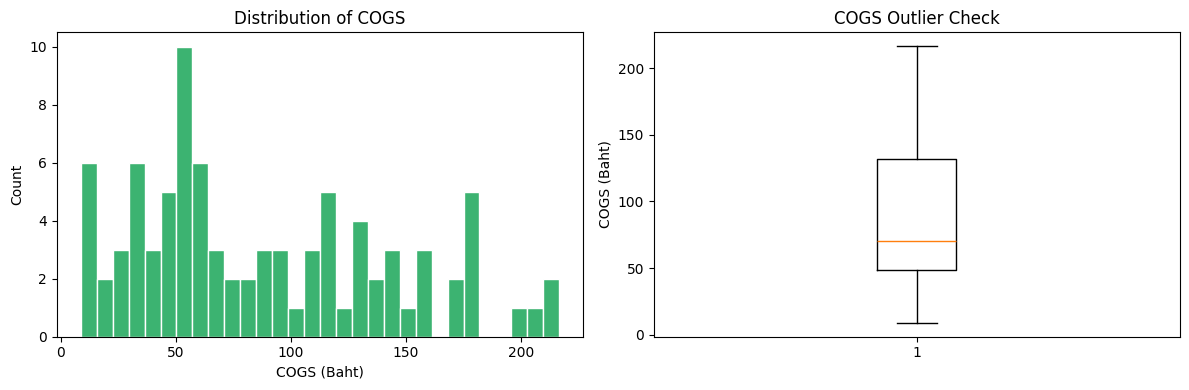

COGS Stats:
count     88.00
mean      88.39
std       55.31
min        8.80
25%       48.48
50%       70.31
75%      132.11
max      216.65
Name: cogs, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# COGS Histogram
axes[0].hist(product['cogs'].dropna(),
             bins=30,
             color='mediumseagreen',
             edgecolor='white')
axes[0].set_title('Distribution of COGS')
axes[0].set_xlabel('COGS (Baht)')
axes[0].set_ylabel('Count')

# COGS Boxplot
axes[1].boxplot(product['cogs'].dropna())
axes[1].set_title('COGS Outlier Check')
axes[1].set_ylabel('COGS (Baht)')

plt.tight_layout()
plt.show()

print('COGS Stats:')
print(product['cogs'].describe().round(2))

## STEP 3: Data Cleaning & Preparation

#### 3.1 Clean sales_transaction

In [12]:
print(f'Original Shape: {sales.shape}')

# 1. drop duplicate rows 
sales = sales.drop_duplicates().reset_index(drop=True)

# 2. parse datetime
sales['datetime'] = pd.to_datetime(sales['datetime'], errors='coerce')

# 3. keep only valid year 2024
sales = sales[sales['datetime'].dt.year == 2024].copy()

# 4. drop rows with missing price
sales = sales[(sales['price'].notna()) & (sales['price'] > 0)].copy()

# 5. remove negative quantity
sales = sales[sales['qty'] > 0].copy()

# 6. Remove quantity outliers
outlier_qty_values = [500, 888, 999]
sales = sales[~sales['qty'].isin(outlier_qty_values)].copy()

# 7. Create revenue column
sales['revenue'] = sales['price'] * sales['qty']

# 8. Create promotion flag
sales['has_promotion'] = sales['promotion_id'].notna().astype(int)

print(f'Cleaned Shape: {sales.shape}')

Original Shape: (5050, 8)
Cleaned Shape: (4869, 10)


#### 3.2 Clean product_master

In [13]:
print(f'Original Shape: {product.shape}')

# 1. drop duplicate rows 
product = product.drop_duplicates(subset=['product_id']).reset_index(drop=True)

# 2. Fill null product_taxonomies to 'unknown'
product['product_taxonomies'] = product['product_taxonomies'].fillna('unknown')

# 3. Normalize product_taxonomies
product['product_taxonomies'] = (product['product_taxonomies'].str.strip().str.lower())

# 4. Strip 'baht' and whitespace from the price, then convert it to float
product['price'] = (
    product['price']
    .astype(str)
    .str.replace(r'[^\d.]', '', regex=True)
)
product['price'] = pd.to_numeric(product['price'], errors='coerce')

# Calculate cogs_ratio
product['cogs_ratio'] = product['cogs'] / product['price']
product['cogs_ratio'] = product['cogs_ratio'].fillna(0)

print(f'Cleaned Shape: {product.shape}')
print(product['product_taxonomies'].value_counts())

Original Shape: (88, 4)
Cleaned Shape: (80, 5)
product_taxonomies
beverage      17
dry_food      13
fresh_food    13
household     13
snack         11
commodity      9
unknown        4
Name: count, dtype: int64


#### 3.3 Clean promotion_master

In [14]:
print(f'Original Shape: {promo.shape}')

promo['start_date'] = pd.to_datetime(
    promo['start_date'],
    errors='coerce'
)

promo['end_date'] = pd.to_datetime(
    promo['end_date'],
    errors='coerce'
)

print(f'Cleaned Shape: {promo.shape}')
print(promo.dtypes)

Original Shape: (40, 5)
Cleaned Shape: (40, 5)
promotion_id            object
discount               float64
product_id              object
start_date      datetime64[ns]
end_date        datetime64[ns]
dtype: object


#### 3.4 Clean Store Master

In [15]:
print(f'Original Shape: {store.shape}')

# Normalize store_taxonomies
store['store_taxonomies'] = (
    store['store_taxonomies']
    .str.strip()
    .str.lower()
    .str.replace(r'\s+store$', '', regex=True)
)

print(f'Cleaned Shape: {store.shape}')

Original Shape: (20, 2)
Cleaned Shape: (20, 2)


In [16]:
print('Unique Store Taxonomies:')
print(store['store_taxonomies'].value_counts())

Unique Store Taxonomies:
store_taxonomies
convenience    6
hypermarket    4
supermarket    4
mini_mart      3
specialty      3
Name: count, dtype: int64


#### 3.5 Clean Customer Master

In [17]:
print(f'Original Shape: {customer.shape}')

# 1. Normalize customer_taxonomies
customer['customer_taxonomies'] = (customer['customer_taxonomies'].str.strip().str.lower())

# 2. Correct the spelling
typo_map = {'ocasional': 'occasional', 'loyl': 'loyal'}
customer['customer_taxonomies'] = customer['customer_taxonomies'].replace(typo_map)

# 3. Fill null customer_taxonomies with 'unknown'
customer['customer_taxonomies'] = customer['customer_taxonomies'].fillna('unknown')

# 4. Drop duplicate rows
customer = customer.drop_duplicates().reset_index(drop=True)

print(f'Cleaned Shape: {customer.shape}')

Original Shape: (515, 2)
Cleaned Shape: (500, 2)


#### 3.6 Merge Dataset

In [18]:
df = (
    sales
    .merge(product[['product_id', 'product_taxonomies', 'cogs_ratio']], on='product_id', how='left')
    .merge(store[['store_id',   'store_taxonomies']], on='store_id', how='left')
    .merge(customer[['customer_id','customer_taxonomies']], on='customer_id', how='left')
    .merge(promo[['promotion_id', 'discount']].drop_duplicates('promotion_id'), on='promotion_id', how='left')
)
df['discount'] = df['discount'].fillna(0)

#### 3.7 Feature Engineering

In [19]:
df['cogs']              = df['price'] * df['cogs_ratio'].fillna(df['cogs_ratio'].median())
df['effective_price']   = df['price'] * (1 - df['discount'])

# Calculate Profit
df['gross_profit']      = (df['effective_price'] - df['cogs']) * df['qty']
df['profit_margin_pct'] = df['gross_profit'] / (df['effective_price'] * df['qty']).replace(0, float('nan')) * 100
df['has_promotion']     = df['promotion_id'].notna()

# About time
df['month']             = df['datetime'].dt.month
df['dayofweek']         = df['datetime'].dt.day_name()

In [20]:
df.head()

,datetime,product_id,price,qty,customer_id,promotion_id,store_id,po_id,revenue,has_promotion,...,cogs_ratio,store_taxonomies,customer_taxonomies,discount,cogs,effective_price,gross_profit,profit_margin_pct,month,dayofweek
0,2024-05-22 19:33:00,P049,103.25,13,C0179,NaN,S20,PO00001,1342.25,False,...,0.505977,convenience,at_risk,0.00,52.242144,103.2500,663.102133,49.402282,5,Wednesday
1,2024-06-28 17:05:00,P001,136.05,6,C0312,NaN,S10,PO00003,816.30,False,...,0.342991,specialty,occasional,0.00,46.663978,136.0500,536.316132,65.700861,6,Friday
2,2024-09-20 12:43:00,P027,145.15,16,C0441,NaN,S19,PO00004,2322.40,False,...,0.467022,mini_mart,loyal,0.00,67.788241,145.1500,1237.788141,53.297801,9,Friday
3,2024-09-18 20:31:00,P078,184.30,12,C0330,NaN,S15,PO00005,2211.60,False,...,0.668993,specialty,churned,0.00,123.295474,184.3000,732.054313,33.100665,9,Wednesday
4,2024-11-03 20:49:00,P057,28.73,21,C0219,PROMO037,S17,PO00006,603.33,True,...,0.627006,convenience,at_risk,0.17,18.013890,23.8459,122.472201,24.457075,11,Sunday


## STEP 4 : Model Selection & Experimenting

#### 4.1 Data Aggregation & Variance Check   
> ปรับข้อมูลการขายให้อยู่ในรูปแบบที่ Model สามารถวิเคราะห์ relationship ของราคาและยอดขายได้
>- **Aggregation:** รวม qty ตามแต่ละ effective_price ของสินค้าแต่ละตัว เพื่อเตรียมวิเคราะห์การตอบสนองต่อราคา
>- **Variance Filtering:** คัดเลือกเฉพาะสินค้าที่มีการปรับราคาอย่างน้อย 5 ระดับ (>= 5 price points) เพื่อให้ค่า Price Elasticity ที่คำนวณได้มีความแม่นยำและน่าเชื่อถือทางสถิติ

In [21]:
# รวมยอดขายตามราคา เพื่อดูคสพ.ระหว่าง Price และ Demand
price_qty = (df.groupby(['product_id', 'product_taxonomies', 'effective_price'])
               .agg(total_qty=('qty', 'sum'), avg_cogs_ratio=('cogs_ratio', 'mean'))
               .reset_index())
price_qty = price_qty[(price_qty['effective_price'] > 0) & (price_qty['total_qty'] > 0)]

# นับจำนวนราคาที่แต่ละสินค้าเคยขาย โดยต้องมีอย่างน้อย 5 price points
price_points = price_qty.groupby('product_id')['effective_price'].nunique()
valid_products = price_points[price_points >= 5].index
price_qty_valid = price_qty[price_qty['product_id'].isin(valid_products)].copy()

print(f"Products with >= 5 price points: {len(valid_products)}")
print(f"Rows for regression : {len(price_qty_valid)}")

Products with >= 5 price points: 80
Rows for regression : 4811


#### 4.2 Price Elasticity Estimation (Log-Log Regression)
> ประมาณค่า Price Elasticity ของสินค้าแต่ละตัวด้วย Log-Log Regression เพื่อวัดว่าลูกค้าไวต่อการเปลี่ยนแปลงราคามากน้อยแค่ไหน แล้วจัดประเภทเป็น Elastic หรือ Inelastic


> **เป้าหมาย** ต้องการตอบคำถามว่า   
"ถ้าราคาของสินค้าเปลี่ยน 1% ยอดขาย(qantity)จะเปลี่ยนกี่ % ?" (ก็คือหลักการ **Price Elasticity of Demand (PED)**)

| Type                       | Meaning                                             |
| -------------------------- | --------------------------------------------------- |
| **Elastic (e < -1)**       | ลูกค้าไวต่อราคา ลดราคาเล็กน้อย ยอดขายเพิ่มมาก       |
| **Inelastic (-1 < e < 0)** | ลูกค้าไม่ค่อยไวต่อราคา ลดราคาแล้ว ยอดขายเพิ่มไม่มาก |
| **Unit Elastic (e = -1)**  | % ยอดขายเปลี่ยนแปลงเท่ากับ % ราคาที่เปลี่ยน         |

In [22]:
elasticity_results = []

for pid in valid_products:
    subset = price_qty_valid[price_qty_valid['product_id'] == pid].copy()
    if len(subset) < 5:
        continue

    log_p = np.log(subset['effective_price'].values)
    log_q = np.log(subset['total_qty'].values)

    # ใช้ stats.linregress เพื่อลากเส้นตรงผ่านจุดข้อมูล เพื่อหา slope (ค่า Elasticity ของสินค้านั้นๆ)
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_p, log_q)

    elasticity_results.append({
        'product_id'        : pid,
        'product_taxonomies': subset['product_taxonomies'].iloc[0],
        'elasticity'        : round(slope, 2),
        'r_squared'         : round(r_value ** 2, 2),
        'p_value'           : round(p_value, 4),
        'avg_price'         : round(subset['effective_price'].mean(), 2),
        'avg_cogs_ratio'    : round(df[df['product_id'] == pid]['cogs_ratio'].mean(), 2),
    })

elast_df = pd.DataFrame(elasticity_results)

# จัดประเภท product ตาม elasticity type
def classify_elasticity(e):
    if e < -1:  return 'elastic'     
    elif e > -1: return 'inelastic'  
    else:        return 'unit_elastic'
elast_df['elasticity_type'] = elast_df['elasticity'].apply(classify_elasticity)

print(f"Elasticity estimated for {len(elast_df)} products")
print("\nElasticity type distribution:")
print(elast_df['elasticity_type'].value_counts().to_string())

print("\nResults:")
print(elast_df.head(8).to_string(index=False))

Elasticity estimated for 80 products

Elasticity type distribution:
elasticity_type
inelastic    53
elastic      27

Results:
product_id product_taxonomies  elasticity  r_squared  p_value  avg_price  avg_cogs_ratio elasticity_type
      P001          commodity       -1.75       0.13   0.0101     141.77            0.34         elastic
      P002          commodity       -2.98       0.66   0.0000     216.89            0.22         elastic
      P003          commodity       -1.59       0.08   0.0228      34.61            0.33         elastic
      P004            unknown       -3.92       0.15   0.0019     254.14            0.20         elastic
      P005            unknown       -3.08       0.72   0.0000     288.57            0.23         elastic
      P006          commodity       -2.62       0.38   0.0000      76.41            0.25         elastic
      P007          commodity       -0.39       0.06   0.0644     152.47            0.24       inelastic
      P008          commodity     

#### 4.3 Visualization: Elasticity Distribution & Category Insights

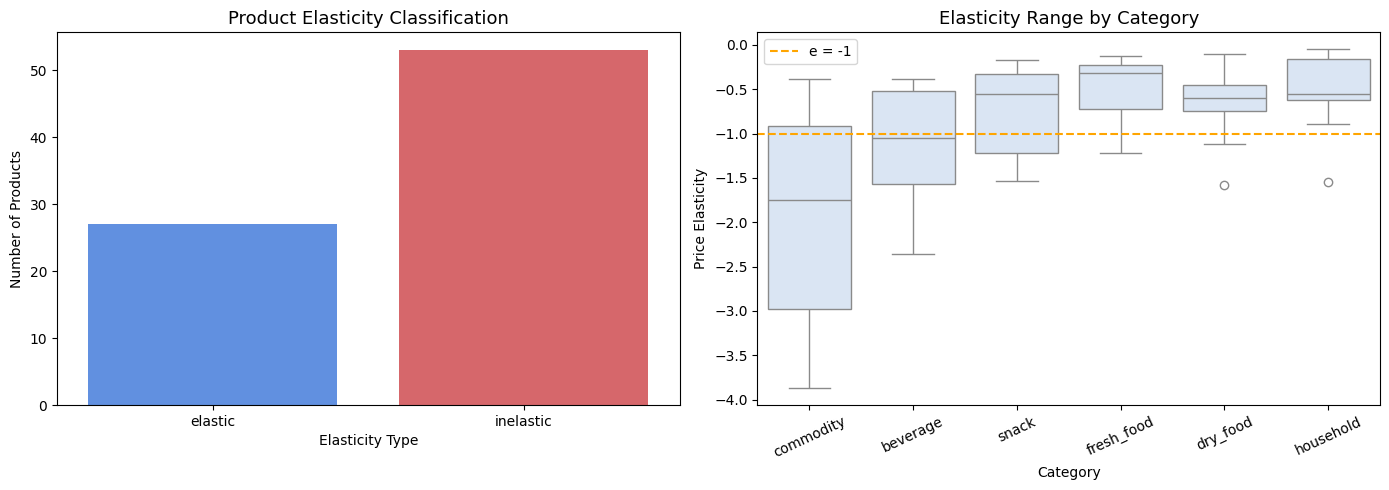

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: bar chart จำนวน elastic vs inelastic
sns.countplot(
    data=elast_df, 
    x='elasticity_type', 
    ax=axes[0], 
    palette={'elastic': '#4C8BF5', 'inelastic': '#E8555A'}
)
axes[0].set_title('Product Elasticity Classification', fontsize=13)
axes[0].set_xlabel('Elasticity Type')
axes[0].set_ylabel('Number of Products')


# Plot 2: boxplot elasticity ต่อ category
plot_data = elast_df[elast_df['product_taxonomies'] != 'unknown']
sns.boxplot(
    data=plot_data, 
    x='product_taxonomies', 
    y='elasticity', 
    ax=axes[1],
    color='#D6E4F7'
)
axes[1].axhline(-1, color='orange', linestyle='--', linewidth=1.5, label='e = -1')
axes[1].set_title('Elasticity Range by Category', fontsize=13)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Price Elasticity')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend()

plt.tight_layout()
plt.show()

#### 4.4 Optimal Discount Calculation
> ใช้ค่า Elasticity ที่หาได้จาก Cell ก่อนหน้า เพื่อทดลองลดราคา 0–40% แล้วเลือกส่วนลดที่ทำให้กำไรสูงสุด
- **หาจุดสมดุล (Optimization) ของกำไร** ซึ่ง Model เราใช้ Brute Force Search (ลองไล่ทุก percent ตั้งแต่ 0 ถึง 40%) เพื่อหาจุดที่กำไรสูงสุด
-  **สร้าง Actionable insight** แบ่งเป็น Increase Discount / Reduce Discount / Keep Current เพื่อให้นำไปตัดสินใจทางธุรกิจได้

In [24]:
def estimate_gross_profit(discount_pct, base_price, cogs_ratio, base_qty, elasticity):
    price_change_pct = -discount_pct                        
    qty_change_pct   = elasticity * price_change_pct 
    new_qty          = base_qty * (1 + qty_change_pct / 100)
    effective_price  = base_price * (1 - discount_pct / 100)
    cogs             = base_price * cogs_ratio  
    gross_profit     = (effective_price - cogs) * max(new_qty, 0)
    return gross_profit

# หา optimal discount ต่อ product (brute force 0-40%)
recommendations = []
discount_range  = np.arange(0, 41, 1) 

for _, row in elast_df.iterrows():
    pid        = row['product_id']
    base_price = row['avg_price']
    cogs_ratio = row['avg_cogs_ratio']
    elasticity = row['elasticity']
    elast_type = row['elasticity_type']

    base_qty = df[df['product_id'] == pid]['qty'].sum()
    if base_qty == 0:
        continue

    # Current avg discount ที่สินค้านี้ได้รับ
    current_disc = df[df['product_id'] == pid]['discount'].mean() * 100

    # หา optimal discount ด้วย brute force
    profits     = [estimate_gross_profit(d, base_price, cogs_ratio, base_qty, elasticity)
                   for d in discount_range]
    optimal_idx  = int(np.argmax(profits))
    optimal_disc = discount_range[optimal_idx]

    # Expected revenue change
    cur_rev  = base_price * (1 - current_disc / 100) * base_qty
    opt_qty  = max(base_qty * (1 + elasticity * (-optimal_disc) / 100), 0)
    opt_rev  = base_price * (1 - optimal_disc / 100) * opt_qty
    exp_rev_change = round((opt_rev - cur_rev) / (cur_rev + 1e-9) * 100, 1)

    # Expected profit change — cap denominator ป้องกัน % มากเกินเมื่อ current_profit ≈ 0
    current_profit = estimate_gross_profit(current_disc, base_price, cogs_ratio, base_qty, elasticity)
    optimal_profit = profits[optimal_idx]
    profit_floor   = max(abs(current_profit), optimal_profit * 0.05 + 1)
    exp_profit_change = round((optimal_profit - current_profit) / profit_floor * 100, 1)

    # Action label
    if optimal_disc > current_disc:
        action = "Increase Discount"
    elif optimal_disc < current_disc:
        action = "Reduce Discount"
    else:
        action = "Keep Current"

    recommendations.append({
        'product_id'                  : pid,
        'product_taxonomies'          : row['product_taxonomies'],
        'elasticity'                  : elasticity,
        'elasticity_type'             : elast_type,
        'current_discount_pct'        : round(current_disc, 1),
        'recommended_discount_pct'    : optimal_disc,
        'expected_revenue_change_pct' : exp_rev_change,
        'expected_profit_change_pct'  : exp_profit_change,
        'action'                      : action,
    })

rec_df = pd.DataFrame(recommendations)

print("\nAction distribution:")
print(f"Optimization Summary for {len(rec_df)} products")
print(rec_df['action'].value_counts().to_string())


Action distribution:
Optimization Summary for 80 products
action
Reduce Discount      49
Keep Current         20
Increase Discount    11


## STEP 5 : Evaluation

#### 5.2 Visualize Baseline vs Model
- **Baseline (Flat 15%):**    
  จำลองว่าถ้าร้านค้าลด 15% ทุกสินค้าเหมือนกัน กำไรรวมจะเป็นเท่าไหร่ โดยใช้ function `estimate_gross_profit` คำนวณออกมา   
- **Model (Optimized):**   
  จำลองกำไรที่เกิดขึ้นเมื่อใช้ค่าส่วนลดที่ Model แนะนำโดยใช้ function `recommended_discount_pct` ของสินค้าแต่ละตัว ซึ่งแต่ละรายการจะมี % ลดไม่เท่ากันตามค่า Elasticity
- **Improvement Calculation:**   
  คำนวณหา "ส่วนต่างกำไร" (Profit Uplift) ว่ากลยุทธ์ใหม่นี้ทำให้กำไรโตขึ้นจากของเดิมกี่ %

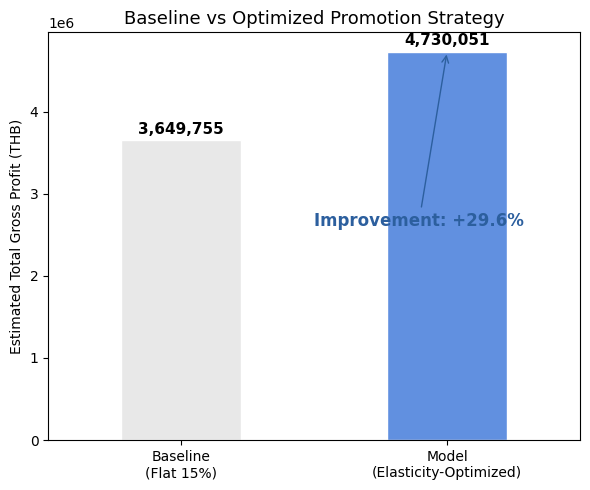

In [25]:
# Simulation & Value Proposition
baseline_profits = []
model_profits    = []

for _, row in rec_df.iterrows():
    pid        = row['product_id']
    base_price = elast_df[elast_df['product_id'] == pid]['avg_price'].values[0]
    cogs_ratio = elast_df[elast_df['product_id'] == pid]['avg_cogs_ratio'].values[0]
    elasticity = row['elasticity']
    base_qty   = df[df['product_id'] == pid]['qty'].sum()

    baseline_p = estimate_gross_profit(15, base_price, cogs_ratio, base_qty, elasticity)
    model_p    = estimate_gross_profit(
                     row['recommended_discount_pct'],
                     base_price, cogs_ratio, base_qty, elasticity)

    baseline_profits.append(baseline_p)
    model_profits.append(model_p)

total_baseline = sum(baseline_profits)
total_model    = sum(model_profits)
improvement    = (total_model - total_baseline) / abs(total_baseline) * 100

# Visualization
labels   = ['Baseline\n(Flat 15%)', 'Model\n(Elasticity-Optimized)']
values   = [total_baseline, total_model]
bar_cols = ['#E8E8E8', '#4C8BF5']

plt.figure(figsize=(6, 5))

ax = sns.barplot(x=labels, y=values, palette=bar_cols, hue=labels, legend=False, edgecolor='white', width=0.45)
plt.ylabel('Estimated Total Gross Profit (THB)')
plt.title('Baseline vs Optimized Promotion Strategy', fontsize=13)

for i, val in enumerate(values):
    ax.text(i, val + (max(values) * 0.01), f'{val:,.0f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

diff_label = f'+{improvement:.1f}%' if improvement >= 0 else f'{improvement:.1f}%'
plt.annotate(f'Improvement: {diff_label}',
             xy=(1, total_model),
             xytext=(0.5, max(values) * 0.55),
             fontsize=12, color='#2C5F9E', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#2C5F9E'))

plt.tight_layout()
plt.show()

#### 5.3 Recommendation Distribution & Discount Space Analysis

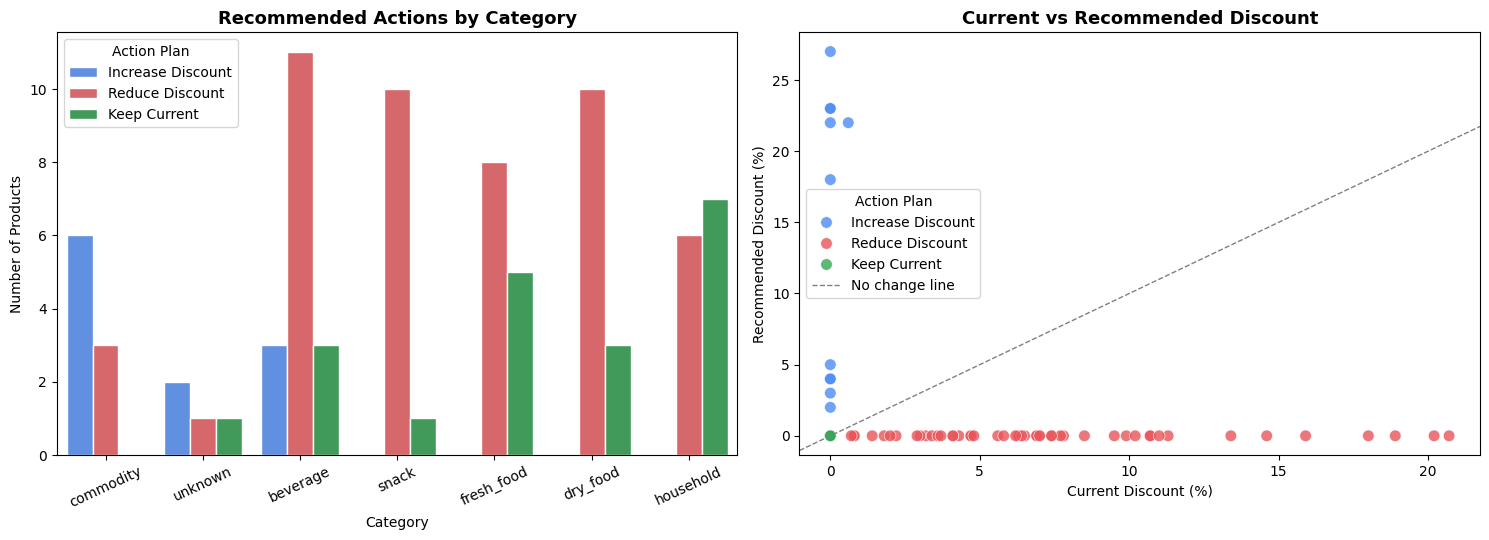

In [26]:
action_colors = {
    'Increase Discount'  : '#4C8BF5',
    'Reduce Discount'    : '#E8555A',
    'Stop Promotion'     : '#888888',
    'Keep Current'       : '#34A853',
    'No Promotion Needed': '#CCCCCC',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Plot 1: Action Breakdown by Category
sns.countplot(
    data=rec_df,
    x='product_taxonomies',
    hue='action',
    palette=action_colors,
    ax=axes[0],
    edgecolor='white'
)
axes[0].set_title('Recommended Actions by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Products')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(title='Action Plan')

# Plot 2: Current vs Recommended Discount (scatter)
sns.scatterplot(
    data=rec_df,
    x='current_discount_pct',
    y='recommended_discount_pct',
    hue='action',
    palette=action_colors,
    s=70,
    alpha=0.8,
    edgecolor='white',
    linewidth=0.5,
    ax=axes[1]
)

axes[1].axline((0, 0), slope=1, color='gray', linestyle='--', linewidth=1, label='No change line')
axes[1].set_title('Current vs Recommended Discount', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Current Discount (%)')
axes[1].set_ylabel('Recommended Discount (%)')
axes[1].legend(title='Action Plan')

plt.tight_layout()
plt.show()

#### 5.4 KPI

##### 5.4.1 คำนวณ Historical Baseline KPIs
คำนวณ KPI จากข้อมูลการขายจริงในอดีต เพื่อใช้เป็น Baseline สำหรับเปรียบเทียบกับผลลัพธ์ที่ได้จากโมเดล

In [27]:
# KPI 1: Profit Margin % ของฝั่ง historical 
valid_m = df[df['profit_margin_pct'].notna() & np.isfinite(df['profit_margin_pct'])]
margin_with_promo    = valid_m[valid_m['has_promotion']]['profit_margin_pct'].mean()
margin_without_promo = valid_m[~valid_m['has_promotion']]['profit_margin_pct'].mean()

# KPI 2: Promotion ROI (Incremental) ของฝั่ง historical
df['discount_cost'] = df['price'] * df['discount'] * df['qty']
promo_tx            = df[df['has_promotion'] & (df['discount_cost'] > 0)]
no_promo_avg_rev    = df[~df['has_promotion']]['revenue'].mean()
total_promo_revenue = promo_tx['revenue'].sum()
incremental_revenue = total_promo_revenue - (no_promo_avg_rev * len(promo_tx))
total_discount_cost = promo_tx['discount_cost'].sum()
promotion_roi       = (incremental_revenue / total_discount_cost) * 100 if total_discount_cost > 0 else 0

#  KPI 3: Promotion Revenue Uplift % ของฝั่ง historical
baseline_rev_per_tx = df[~df['has_promotion']]['revenue'].mean()
promo_rev_per_tx    = df[df['has_promotion']]['revenue'].mean()
uplift_pct          = (promo_rev_per_tx - baseline_rev_per_tx) / baseline_rev_per_tx * 100 if baseline_rev_per_tx > 0 else 0

##### 5.4.2 Model Simulation
จำลองผลลัพธ์ทางธุรกิจภายใต้กลยุทธ์ส่วนลดที่ Model แนะนำ โดยใช้ค่า Price Elasticity ของแต่ละสินค้าในการประมาณการยอดขาย รายได้ และกำไรที่คาดว่าจะเกิดขึ้น  
ผลลัพธ์ที่ได้จะถูกนำไปคำนวณ KPI เพื่อเปรียบเทียบกับ Historical Baseline

In [28]:
sim_model_rev        = 0
sim_model_profit     = 0
sim_model_dist_cost  = 0

# 1. Historical Baseline จากข้อมูลจริงที่ไม่จัด promotion (สำหรับฝั่ง Simulation)
historical_base = df[df['product_id'].isin(rec_df['product_id']) & ~df['has_promotion']].copy()
historical_rev = historical_base['revenue'].sum()
historical_profit = historical_base['gross_profit'].sum()

# 2. Simulation ด้วย Model strategy ของเรา
for _, row in rec_df.iterrows():
    # ดึงค่า parameter พื้นฐานของ product 
    pid        = row['product_id']
    base_price = elast_df[elast_df['product_id'] == pid]['avg_price'].values[0]
    cogs_ratio = elast_df[elast_df['product_id'] == pid]['avg_cogs_ratio'].values[0]
    elasticity = row['elasticity']
    base_qty   = df[df['product_id'] == pid]['qty'].sum()
    
    # ส่วนลดที่ model เลือก (แปลงเป็นทศนิยม)
    opt_discount = row['recommended_discount_pct'] / 100
    
    # คำนวณปริมาณสินค้าที่คาดว่าจะขายได้ตามค่า Elasticity
    price_change_pct = -opt_discount
    sim_qty = max(0, min(base_qty * (1 + elasticity * price_change_pct), base_qty * 2.0))
    
    # คำนวณราคาขายจริง และต้นทุน
    sim_price   = base_price * (1 - opt_discount)
    sim_cogs    = base_price * cogs_ratio
    
    # สะสมยอดรวมรายได้ กำไร และต้นทุนส่วนลดจากสินค้าทุกตัว
    sim_model_rev        += sim_qty * sim_price
    sim_model_profit     += sim_qty * (sim_price - sim_cogs)
    sim_model_dist_cost  += sim_qty * base_price * opt_discount

# คำนวณ KPIs สำหรับฝั่ง Model Forecast
model_margin_pct = (sim_model_profit / sim_model_rev) * 100 if sim_model_rev > 0 else 0
sim_incremental_profit = sim_model_profit - historical_profit
model_roi_pct = (sim_incremental_profit / sim_model_dist_cost) * 100 if sim_model_dist_cost > 0 else 0
model_uplift_pct = ((sim_model_rev - historical_rev) / historical_rev) * 100 if historical_rev > 0 else 0

##### 5.4.3 KPI Summary
เปรียบเทียบประสิทธิภาพของกลยุทธ์โปรโมชั่นเดิม (Historical) กับกลยุทธ์ที่ปรับด้วย Price Elasticity-Based Promotion Optimizer

In [29]:
print("KPI Comparison")
print(f"KPI 1 | Profit Margin %")
print(f"         • Historical (With Promo)   : {margin_with_promo:.1f}%")
print(f"         • Optimized (Model Forecast): {model_margin_pct:.1f}%")
print()
print(f"KPI 2 | Promotion ROI (Incremental)")
print(f"         • Historical (As-Is)        : {promotion_roi:.1f}%")
print(f"         • Optimized (Model Forecast): {model_roi_pct:.1f}%")
print()
print(f"KPI 3 | Revenue Uplift")
print(f"         • Historical (As-Is)        : {uplift_pct:+.1f}%")
print(f"         • Optimized (Model Forecast): {model_uplift_pct:+.1f}%")

KPI Comparison
KPI 1 | Profit Margin %
         • Historical (With Promo)   : 19.1%
         • Optimized (Model Forecast): 46.4%

KPI 2 | Promotion ROI (Incremental)
         • Historical (As-Is)        : 71.3%
         • Optimized (Model Forecast): 249.8%

KPI 3 | Revenue Uplift
         • Historical (As-Is)        : +23.1%
         • Optimized (Model Forecast): +23.6%


## STEP 6 : Deployment

#### 6.1 Business Action Plan
ให้ธุรกิจนำไปปรับใช้จริง โดยเรียงลำดับตามสินค้าที่ Model คาดว่าจะสร้างกำไรเพิ่มได้มากที่สุด

In [30]:
output_cols = [
    'product_id', 'product_taxonomies',
    'current_discount_pct', 'recommended_discount_pct',
    'expected_revenue_change_pct', 'expected_profit_change_pct',
    'action', 'elasticity_type'
]
output_table = rec_df[output_cols].sort_values('expected_profit_change_pct', ascending=False)
output_table.to_csv('./output/promotion_recommendation.csv',index=False, encoding='utf-8-sig')

In [31]:
output_table.head()

,product_id,product_taxonomies,current_discount_pct,recommended_discount_pct,expected_revenue_change_pct,expected_profit_change_pct,action,elasticity_type
40,P041,fresh_food,20.2,0,25.3,110.0,Reduce Discount,inelastic
61,P062,dry_food,20.7,0,26.1,90.0,Reduce Discount,inelastic
44,P045,fresh_food,18.9,0,23.2,68.0,Reduce Discount,inelastic
41,P042,fresh_food,18.0,0,22.0,56.9,Reduce Discount,inelastic
62,P063,dry_food,11.0,0,12.3,39.0,Reduce Discount,inelastic


#### 6.2 BI Dashboard Data
เพื่อนำไปจัดทำ Dashboard บน Power BI

In [40]:
bi_data = []

for _, row in rec_df.iterrows():
    pid = row['product_id']
    p_info = elast_df[elast_df['product_id'] == pid].iloc[0]
    base_price = p_info['avg_price']
    cogs_ratio = p_info['avg_cogs_ratio']
    elasticity = row['elasticity']
    
    # ดึงรายการยอดขายจริงทั้งหมดของสินค้าชิ้นนั้นๆ
    product_sales = df[df['product_id'] == pid]

    current_disc_val = row['current_discount_pct'] / 100
    opt_disc_val = row['recommended_discount_pct'] / 100

    for _, sale_row in product_sales.iterrows():
        base_qty = sale_row['qty']
        
        # คำนวณ Base Financials
        base_rev = base_price * (1 - current_disc_val) * base_qty
        base_profit = (base_price * (1 - current_disc_val) - (base_price * cogs_ratio)) * base_qty

        # คำนวณ Simulated Financials
        sim_qty = base_qty * (1 + elasticity * (-opt_disc_val))
        sim_qty = max(0, sim_qty) 
        sim_rev = base_price * (1 - opt_disc_val) * sim_qty
        sim_profit = (base_price * (1 - opt_disc_val) - (base_price * cogs_ratio)) * sim_qty
        dist_cost = base_price * opt_disc_val * sim_qty

        bi_data.append({
            'datetime': sale_row['datetime'],     
            'store_id': sale_row['store_id'],
            'store_taxonomies': sale_row['store_taxonomies'],       
            'customer_id': sale_row['customer_id'], 
            'customer_taxonomies': sale_row['customer_taxonomies'], 
            'product_id': pid,
            'product_taxonomies': row['product_taxonomies'],
            'action': row['action'],
            'elasticity_type': row['elasticity_type'],
            'current_discount_pct': row['current_discount_pct'],
            'recommended_discount_pct': row['recommended_discount_pct'],
            'expected_revenue_change_pct': row['expected_revenue_change_pct'], 
            'expected_profit_change_pct': row['expected_profit_change_pct'],   
            'base_qty': base_qty,
            'simulated_qty': round(sim_qty, 2),
            'base_revenue': round(base_rev, 2),
            'base_profit': round(base_profit, 2),
            'simulated_revenue': round(sim_rev, 2),
            'simulated_profit': round(sim_profit, 2),
            'estimated_discount_cost': round(dist_cost, 2)
        })

df_for_bi = pd.DataFrame(bi_data)
# แปลงคอลัมน์ datetime ให้เป็นข้อความมาตรฐานที่ Power BI อ่านง่ายชัวร์ๆ (ลดปัญหา Error)
df_for_bi = df_for_bi.dropna(subset=['datetime'])
df_for_bi['customer_taxonomies'] = df_for_bi['customer_taxonomies'].fillna('General Customer')
df_for_bi.to_csv('./output/powerbi_dashboard_data.csv', index=False, encoding='utf-8-sig')